# PROG71090 Final Project: Glassdoor Review Analyzer 
### Adam Berbash, Destiny Louangsombath, Hajun Huh, Nour Tamam
### 04/10/26

This project examines a large dataset of over 8 million job reviews from Glassdoor. Our team used Python to perform various data analysis tasks on this data, to make draw relevant insights. This Jupyter Notebook will demonstrate descriptive statistics, bucketing and data visualizations. To view specific implementation of the SimpleReview and ReviewAnalyser classes, please see the "examples" and "tests" folders.  

In [10]:
import pandas as pd
import numpy as np 
import matplotlib as plt 
import seaborn as sns 
import statistics

from simple_review import SimpleReview, simple_bucket

filename = "../data/all_reviews.csv"


## Descriptive Statistics 
The SimpleReview class takes long, complex reviews and extracts only the most relevant columns to create a more concise general summary. Using the SimpleReview class, we can take a sample of all reviews and perform descriptive statistics. Since there are over 8 million reviews in the data file, we will demonstrate this using only the first 50 rows of data. 

In [11]:
# Reading first 50 because the data is very large 
df = pd.read_csv(filename, usecols=simple_bucket, nrows=50)

# Put the 50 reviews in a list 
simple_reviews = []
for row in df.itertuples(index=False): 
    review = SimpleReview(row.rating, row.status, row.job, row.title)
    simple_reviews.append(review)

ratings = [r.rating for r in simple_reviews]

print("DESCRIPTIVE STATISTICS")
print(f"Total Reviews: {len(ratings)}" )
print(f"Mean Rating: {statistics.mean(ratings)}")
print(f"Median Rating: {statistics.median(ratings)}")
print(f"Standard Deviation: {statistics.stdev(ratings)}")
print(f"Minimum Rating: {min(ratings)}" )
print(f"Maximum Rating: {max(ratings)}")

# Counts of happiness 
for r in simple_reviews: 
    r.set_summary("happiness")
happiness_categories = [r.get_summary() for r in simple_reviews]
happiness_counts = pd.Series(happiness_categories).value_counts()
print("\nHAPPINESS COUNTS")
print(happiness_counts)

DESCRIPTIVE STATISTICS
Total Reviews: 50
Mean Rating: 3.4
Median Rating: 4.0
Standard Deviation: 1.324802642213672
Minimum Rating: 1.0
Maximum Rating: 5.0

HAPPINESS COUNTS
happy      28
unhappy    12
neutral    10
Name: count, dtype: int64


## Bucketing
Using the SimpleReview class again, we will change the summary strategy to "satisfaction." The satisfaction is the star rating converted to a percentage. We will create buckets that represent satisfaction thresholds and output the total employees that fall within these thresholds. 

In [12]:
# Change summary strategy to satisfaction 
for r in simple_reviews: 
    r.set_summary("satisfaction")

# Create list of satisfaction percentages only 
s_percentages = [r.get_summary() for r in simple_reviews]

s_buckets = [25, 50, 75]
for x in s_buckets: 
    total = sum(percentage >= x for percentage in s_percentages)
    print(f"{total} employees were more than {x}% satisfied with their job.")

43 employees were more than 25% satisfied with their job.
38 employees were more than 50% satisfied with their job.
28 employees were more than 75% satisfied with their job.


## Data Visualizatons

The following visualizations will showcase the distributions for: 
* Overall Job Rating 
* Overall Employee Happiness 
* CEO Approval 

In [13]:
# import functions
from simple_review import happiness

# set chart style
sns.set_style("dark", rc={"axes.facecolor": "lavender", "figure.facecolor": "lavender",'axes.edgecolor': 'lavender','axes.spines': 'black'})

In [14]:
# Creating vizualizations with first 100,000 rows
df2 = pd.read_csv(filename, usecols=simple_bucket, nrows=100000)
df3 = pd.read_csv(filename, nrows=100000)

# Count ratings distribution
df2['rating_count'] = df2.groupby('rating')['rating'].transform('count')

# Create happiness column
df2['happiness'] = df2['rating'].apply(happiness)

# Count happiness distribution
df2['happiness_count'] = df2.groupby('happiness')['happiness'].transform('count')

Text(0.5, 1.0, 'Ratings Distribution')

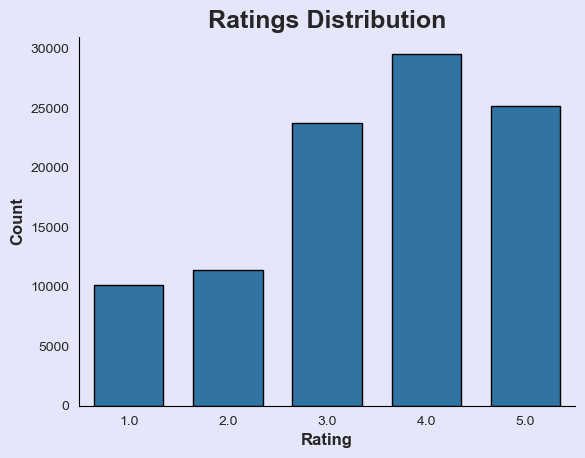

In [15]:
# Plot ratings distribution chart
viz = sns.barplot(data=df2, x='rating', y='rating_count', edgecolor='black', width=0.7)
viz.set_xlabel('Rating', fontsize=12, fontweight='bold')
viz.set_ylabel('Count', fontsize=12, fontweight='bold')
viz.spines['bottom'].set_color('black')
viz.spines['left'].set_color('black')
viz.set_title('Ratings Distribution', fontsize=18, fontweight='bold')

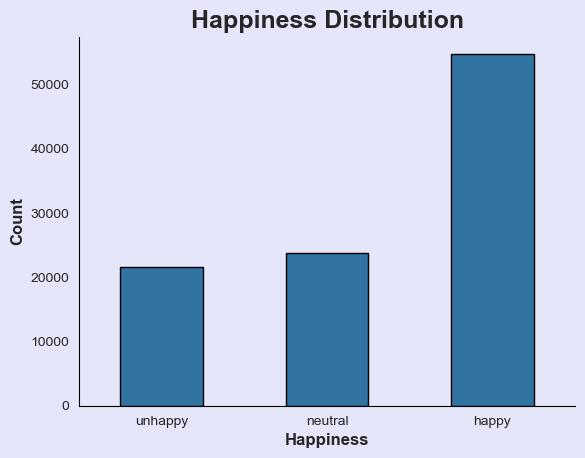

In [16]:
# Plot happiness distribution chart
viz2 = sns.barplot(data=df2, x='happiness', y='happiness_count', order=["unhappy", "neutral", "happy"], edgecolor='black', width=0.5)
viz2.set_title("Happiness Distribution", fontsize=18, fontweight='bold')
viz2.set_xlabel('Happiness', fontsize=12, fontweight='bold')
viz2.set_ylabel('Count', fontsize=12, fontweight='bold')
viz2.spines['bottom'].set_color('black')
viz2.spines['left'].set_color('black')

In [17]:
# Replace CEO Approval with plain english
df3['CEO Approval'] = df3['CEO Approval'].replace('o', 'No opinion')
df3['CEO Approval'] = df3['CEO Approval'].replace('x', 'Negative opinion')
df3['CEO Approval'] = df3['CEO Approval'].replace('r', 'Neutral opinion')
df3['CEO Approval'] = df3['CEO Approval'].replace('v', 'Positive opinion')

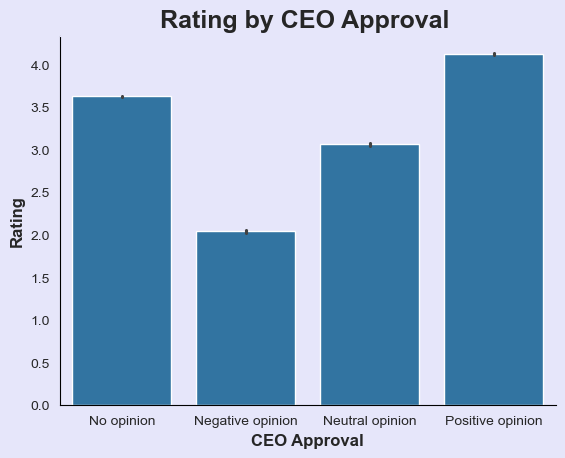

In [18]:
# Plot Employee Rating by CEO Approval
viz3 = sns.barplot(data=df3, x="CEO Approval", y="rating")
viz3.set_title("Rating by CEO Approval ", fontsize=18, fontweight='bold')
viz3.set_xlabel('CEO Approval', fontsize=12, fontweight='bold')
viz3.set_ylabel('Rating', fontsize=12, fontweight='bold')
viz3.spines['bottom'].set_color('black')
viz3.spines['left'].set_color('black')